# Hab/Dishab Mean DA During Full Bout, Investigation, and Non-Investigation

This notebook extracts mean DA for each Hab/Dishab bout in both `mPFC` and `NAc` using three windows:

- `full_bout`: the full bout from introduction to removal
- `investigation`: only frames annotated as `Investigation`
- `non_investigation`: the rest of the bout outside `Investigation`

Plots are generated with the same bar-plus-paired-subject-line format as `plot_behavior_across_bouts_no_identities`, and paired statistics are saved for each plot.

In [2]:
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'Hab_Dishab' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from bouts_extension import plot_behavior_across_bouts_no_identities
from experiment_class import Experiment

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

In [3]:
REGION_CONFIGS = {
    'mPFC': {
        'experiment_path': r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc",
        'csv_path': r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc_csvs",
        'color': '#FFAF00',
        'ylim': (-3, 3),
    },
    'NAc': {
        'experiment_path': r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac",
        'csv_path': r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac_csvs",
        'color': '#15616F',
        'ylim': (-3, 3),
    },
}

SELECTED_REGIONS = ['NAc', 'mPFC']
BOUT_DEFINITIONS = [
    {'prefix': 's1', 'introduced': 's1_Introduced', 'removed': 's1_Removed'},
    {'prefix': 's2', 'introduced': 's2_Introduced', 'removed': 's2_Removed'},
]
BOUT_ORDER = ['s1-1', 's1-2', 's1-3', 's1-4', 's1-5', 's2-1']
WINDOW_ORDER = ['full_bout', 'investigation', 'non_investigation']
WINDOW_LABELS = {
    'full_bout': 'Full Bout Mean',
    'investigation': 'Investigation Mean',
    'non_investigation': 'Non-Investigation Mean',
}
SIGNAL_NAME = 'zscore'
SIGNAL_COLUMN = 'Mean Z-score'
CUSTOM_XTICK_LABELS = ['i1', 'i1', 'i1', 'i1', 'i1', 'i2']
CUSTOM_XTICK_COLORS = ['blue', 'blue', 'blue', 'blue', 'blue', '#E06928']
YTICKS_INCREMENT = 1

OUTPUT_DIR = PROJECT_ROOT / 'Hab_Dishab' / 'mpfc_bout_mean_da_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

WindowsPath('C:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Hab_Dishab/mpfc_bout_mean_da_outputs')

In [4]:
def load_region_experiment(region_name):
    config = REGION_CONFIGS[region_name]
    exp = Experiment(config['experiment_path'], config['csv_path'])
    exp.default_batch_process()
    exp.group_extract_manual_annotations(BOUT_DEFINITIONS, first_only=False)
    return exp


def get_signal_array(trial, signal_name='zscore'):
    if not hasattr(trial, signal_name):
        raise AttributeError(f"Trial does not have signal '{signal_name}'")
    return np.asarray(getattr(trial, signal_name), dtype=float)


def merge_intervals(intervals):
    cleaned = sorted(
        (float(start), float(end))
        for start, end in intervals
        if pd.notna(start) and pd.notna(end) and end > start
    )
    if not cleaned:
        return []

    merged = [cleaned[0]]
    for start, end in cleaned[1:]:
        last_start, last_end = merged[-1]
        if start <= last_end:
            merged[-1] = (last_start, max(last_end, end))
        else:
            merged.append((start, end))
    return merged


def subtract_intervals(base_interval, intervals):
    base_start, base_end = map(float, base_interval)
    remaining = [(base_start, base_end)]

    for cut_start, cut_end in merge_intervals(intervals):
        updated = []
        for seg_start, seg_end in remaining:
            if cut_end <= seg_start or cut_start >= seg_end:
                updated.append((seg_start, seg_end))
                continue
            if cut_start > seg_start:
                updated.append((seg_start, cut_start))
            if cut_end < seg_end:
                updated.append((cut_end, seg_end))
        remaining = updated

    return [(start, end) for start, end in remaining if end > start]


def intervals_mean(timestamps, signal, intervals):
    pooled = []
    total_n = 0
    for start, end in intervals:
        mask = (timestamps >= start) & (timestamps <= end)
        values = signal[mask]
        values = values[~np.isnan(values)]
        if values.size == 0:
            continue
        pooled.append(values)
        total_n += int(values.size)

    if not pooled:
        return np.nan, 0

    pooled = np.concatenate(pooled)
    return float(np.nanmean(pooled)), total_n


def build_window_metadata(experiment, region_name, signal_name='zscore'):
    rows = []
    for trial_name, trial in experiment.trials.items():
        timestamps = np.asarray(trial.timestamps, dtype=float)
        signal = get_signal_array(trial, signal_name=signal_name)
        behaviors = trial.behaviors.copy()

        for bout_label, (bout_start, bout_end) in trial.bouts.items():
            investigation_df = behaviors[
                (behaviors['Bout'] == bout_label) & (behaviors['Behavior'] == 'Investigation')
            ].copy()
            investigation_intervals = merge_intervals(
                list(zip(investigation_df['Event_Start'], investigation_df['Event_End']))
            )
            window_intervals = {
                'full_bout': [(float(bout_start), float(bout_end))],
                'investigation': investigation_intervals,
                'non_investigation': subtract_intervals((bout_start, bout_end), investigation_intervals),
            }

            for window_name, intervals in window_intervals.items():
                mean_signal, n_samples = intervals_mean(timestamps, signal, intervals)
                rows.append(
                    {
                        'BrainRegion': region_name,
                        'trial_name': trial_name,
                        'Subject': trial.subject_name,
                        'Bout': bout_label,
                        'Behavior': window_name,
                        SIGNAL_COLUMN: mean_signal,
                        'N_Samples': n_samples,
                        'Window_Duration_s': float(sum(end - start for start, end in intervals)),
                        'SignalName': signal_name,
                    }
                )

    out = pd.DataFrame(rows)
    out['Bout'] = pd.Categorical(out['Bout'], categories=BOUT_ORDER, ordered=True)
    out['Behavior'] = pd.Categorical(out['Behavior'], categories=WINDOW_ORDER, ordered=True)
    return out.sort_values(['BrainRegion', 'Behavior', 'Bout', 'Subject']).reset_index(drop=True)


def build_all_region_metadata(region_names, signal_name='zscore'):
    parts = []
    for region_name in region_names:
        exp = load_region_experiment(region_name)
        parts.append(build_window_metadata(exp, region_name=region_name, signal_name=signal_name))
    return pd.concat(parts, ignore_index=True)


def holm_correct_stats(stats_df, alpha=0.05):
    corrected = stats_df.copy()
    corrected['p_adj'] = np.nan
    corrected['reject'] = False
    valid_mask = corrected['p_value'].notna()
    if valid_mask.any():
        reject, p_adj, _, _ = multipletests(corrected.loc[valid_mask, 'p_value'], alpha=alpha, method='holm')
        corrected.loc[valid_mask, 'p_adj'] = p_adj
        corrected.loc[valid_mask, 'reject'] = reject
    corrected['significance'] = np.where(corrected['reject'], 'sig', 'ns')
    return corrected


def run_within_bout_window_stats(metadata_df, region_name, value_col=SIGNAL_COLUMN):
    region_df = metadata_df[metadata_df['BrainRegion'] == region_name].copy()
    results = []

    for bout in BOUT_ORDER:
        bout_df = region_df[region_df['Bout'] == bout].copy()
        pivot = bout_df.pivot(index='Subject', columns='Behavior', values=value_col)
        pivot = pivot.reindex(columns=WINDOW_ORDER)

        for a, b in combinations(WINDOW_ORDER, 2):
            pair = pivot[[a, b]].dropna()
            if len(pair) < 2:
                results.append(
                    {
                        'BrainRegion': region_name,
                        'Bout': bout,
                        'comparison': f'{a} vs {b}',
                        'n': len(pair),
                        't_stat': np.nan,
                        'p_value': np.nan,
                        'cohen_d': np.nan,
                    }
                )
                continue

            t_stat, p_val = ttest_rel(pair[a], pair[b])
            diff = pair[a] - pair[b]
            diff_std = diff.std(ddof=1)
            cohen_d = diff.mean() / diff_std if diff_std != 0 else np.nan

            results.append(
                {
                    'BrainRegion': region_name,
                    'Bout': bout,
                    'comparison': f'{a} vs {b}',
                    'n': len(pair),
                    't_stat': t_stat,
                    'p_value': p_val,
                    'cohen_d': cohen_d,
                }
            )

    stats_df = pd.DataFrame(results)
    corrected_parts = []
    for bout in BOUT_ORDER:
        bout_stats = stats_df[stats_df['Bout'] == bout].copy()
        corrected_parts.append(holm_correct_stats(bout_stats))
    return pd.concat(corrected_parts, ignore_index=True)


In [5]:
metadata_df = build_all_region_metadata(SELECTED_REGIONS, signal_name=SIGNAL_NAME)
metadata_df = metadata_df[metadata_df['Bout'].astype(str).isin(BOUT_ORDER)].copy()
metadata_df['Bout'] = pd.Categorical(metadata_df['Bout'].astype(str), categories=BOUT_ORDER, ordered=True)
metadata_df.to_csv(OUTPUT_DIR / f'{SIGNAL_NAME}_window_means_by_subject_all_regions.csv', index=False)
metadata_df.head(18)

Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac\n6-240821-100116\Notes.txt
read from t=0s to t=1335.06s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac\n7-240821-114717\Notes.txt
read from t=0s to t=1309.86s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac\nn1-250115-052028\Notes.txt
read from t=0s to t=1351.05s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac\nn2-250115-054951\Notes.txt
read from t=0s to t=1349.96s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac\nn3-250115-064154\Notes.txt
read from t=0s to t=1377.67s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac\nn4

,BrainRegion,trial_name,Subject,Bout,Behavior,Mean Z-score,N_Samples,Window_Duration_s,SignalName
0,NAc,n6-240821-100116,n6,s1-1,full_bout,0.650249,12061,120.6,zscore
1,NAc,n7-240821-114717,n7,s1-1,full_bout,0.252137,12171,121.7,zscore
2,NAc,nn1-250115-052028,nn1,s1-1,full_bout,0.137201,12341,123.4,zscore
3,NAc,nn2-250115-054951,nn2,s1-1,full_bout,0.257458,12201,122.0,zscore
4,NAc,nn3-250115-064154,nn3,s1-1,full_bout,0.299961,12281,122.8,zscore
5,NAc,nn4-250115-072812,nn4,s1-1,full_bout,0.702805,12211,122.1,zscore
6,NAc,nn5-250114-083827,nn5,s1-1,full_bout,0.104840,12221,122.2,zscore
7,NAc,nn6-250114-093117,nn6,s1-1,full_bout,0.569118,12181,121.8,zscore
8,NAc,nn7-250114-100133,nn7,s1-1,full_bout,-0.018825,12211,122.1,zscore
9,NAc,nn8-250114-103839,nn8,s1-1,full_bout,0.390240,12351,123.5,zscore


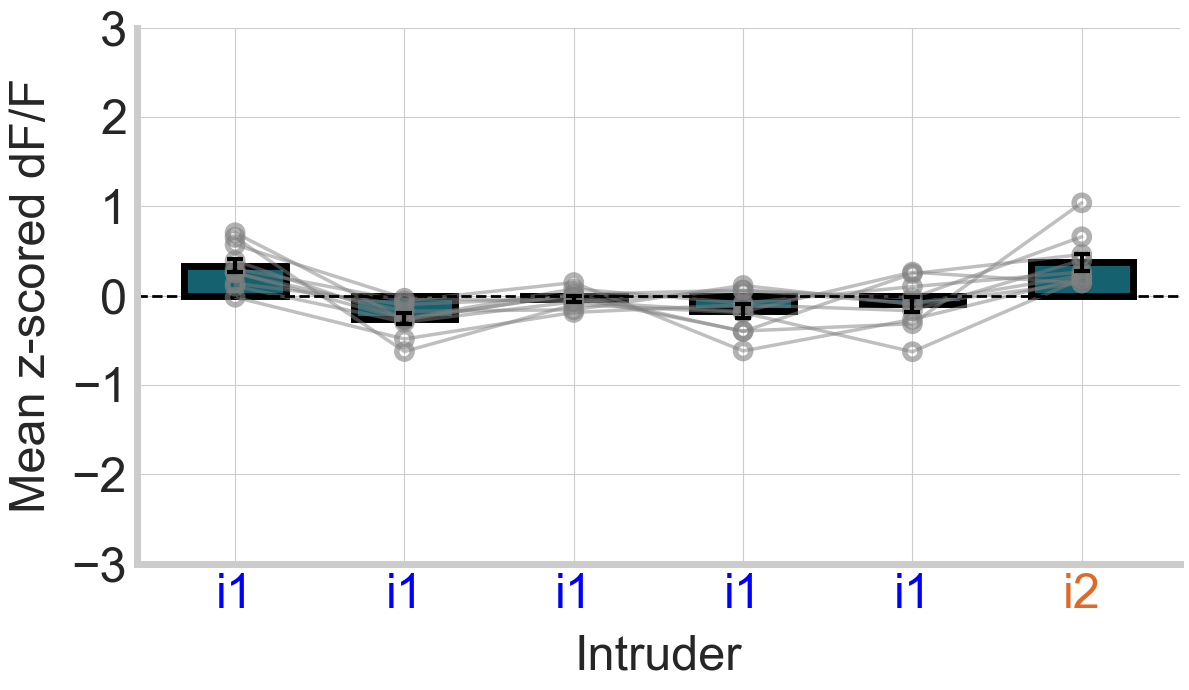


Paired t-test results:
  comparison  n  t_stat  p_value  cohen_d
s1-1 vs s1-2 10  5.9940   0.0002   1.8955
s1-1 vs s1-3 10  4.9391   0.0008   1.5619
s1-1 vs s1-4 10  4.2015   0.0023   1.3286
s1-1 vs s1-5 10  4.2043   0.0023   1.3295
s1-1 vs s2-1 10 -0.2585   0.8018  -0.0817
s1-2 vs s1-3 10 -4.2269   0.0022  -1.3367
s1-2 vs s1-4 10 -0.7620   0.4655  -0.2410
s1-2 vs s1-5 10 -2.0704   0.0683  -0.6547
s1-2 vs s2-1 10 -6.1089   0.0002  -1.9318
s1-3 vs s1-4 10  1.4216   0.1889   0.4495
s1-3 vs s1-5 10  0.7260   0.4863   0.2296
s1-3 vs s2-1 10 -4.2193   0.0022  -1.3343
s1-4 vs s1-5 10 -0.7229   0.4881  -0.2286
s1-4 vs s2-1 10 -4.2231   0.0022  -1.3355
s1-5 vs s2-1 10 -3.5865   0.0059  -1.1342


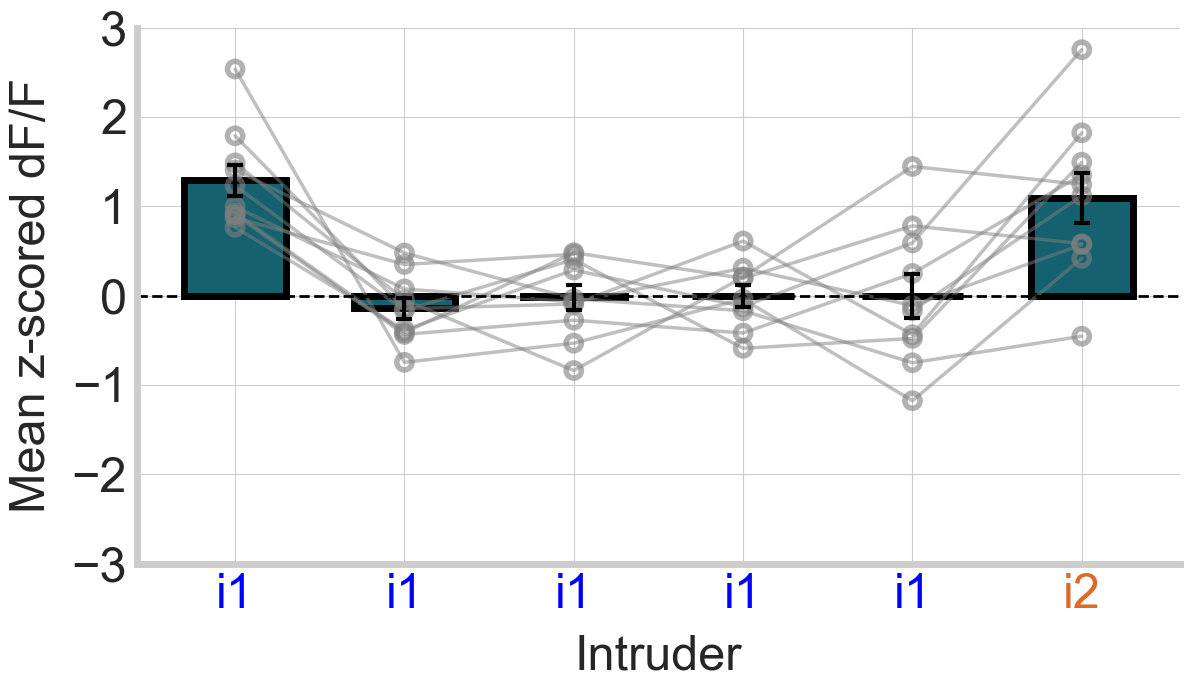


Paired t-test results:
  comparison  n  t_stat  p_value  cohen_d
s1-1 vs s1-2 10  6.0112   0.0002   1.9009
s1-1 vs s1-3 10  4.6948   0.0011   1.4846
s1-1 vs s1-4  9  6.7488   0.0001   2.2496
s1-1 vs s1-5 10  3.5095   0.0066   1.1098
s1-1 vs s2-1 10  0.5471   0.5976   0.1730
s1-2 vs s1-3 10 -0.7502   0.4723  -0.2372
s1-2 vs s1-4  9 -1.2162   0.2586  -0.4054
s1-2 vs s1-5 10 -0.4931   0.6337  -0.1559
s1-2 vs s2-1 10 -3.6707   0.0051  -1.1608
s1-3 vs s1-4  9 -0.3434   0.7402  -0.1145
s1-3 vs s1-5 10 -0.0508   0.9606  -0.0160
s1-3 vs s2-1 10 -3.8445   0.0039  -1.2157
s1-4 vs s1-5  9 -0.0507   0.9608  -0.0169
s1-4 vs s2-1  9 -3.2418   0.0118  -1.0806
s1-5 vs s2-1 10 -3.7422   0.0046  -1.1834


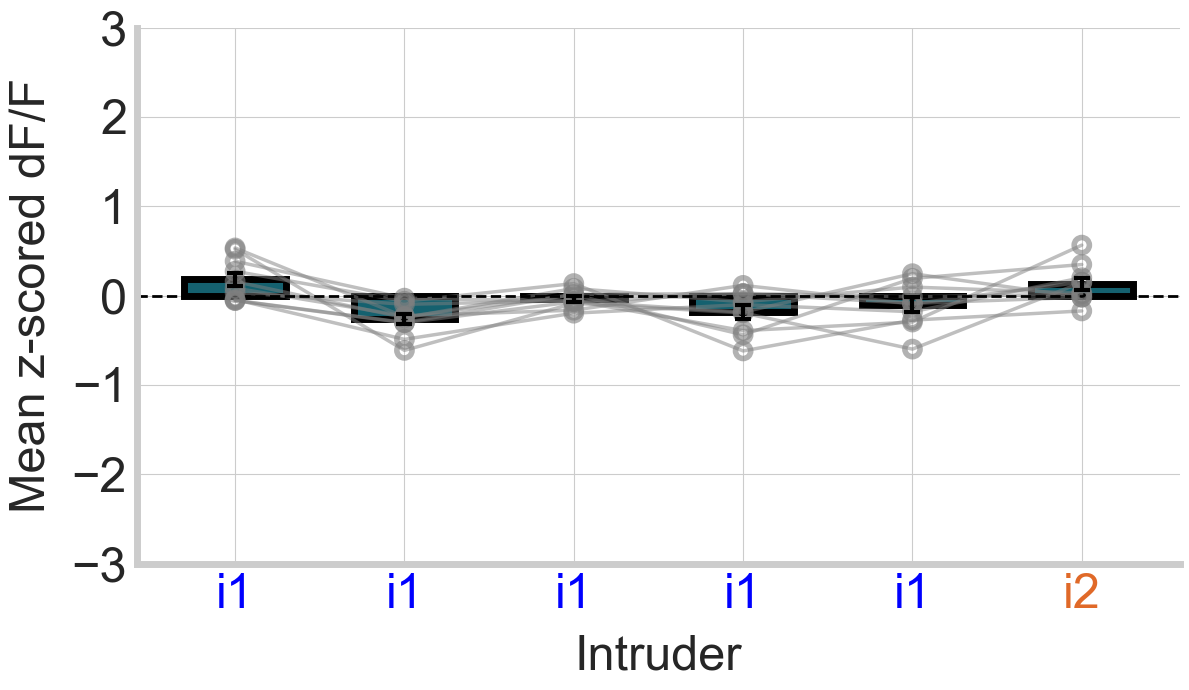


Paired t-test results:
  comparison  n  t_stat  p_value  cohen_d
s1-1 vs s1-2 10  4.7599   0.0010   1.5052
s1-1 vs s1-3 10  3.1034   0.0127   0.9814
s1-1 vs s1-4 10  2.8705   0.0185   0.9077
s1-1 vs s1-5 10  2.6425   0.0268   0.8356
s1-1 vs s2-1 10  0.5963   0.5657   0.1886
s1-2 vs s1-3 10 -4.2531   0.0021  -1.3450
s1-2 vs s1-4 10 -0.7007   0.5012  -0.2216
s1-2 vs s1-5 10 -2.2665   0.0496  -0.7167
s1-2 vs s2-1 10 -4.2024   0.0023  -1.3289
s1-3 vs s1-4 10  1.5102   0.1653   0.4776
s1-3 vs s1-5 10  0.7476   0.4738   0.2364
s1-3 vs s2-1 10 -1.9449   0.0836  -0.6150
s1-4 vs s1-5 10 -0.8326   0.4266  -0.2633
s1-4 vs s2-1 10 -2.8884   0.0179  -0.9134
s1-5 vs s2-1 10 -2.0390   0.0719  -0.6448


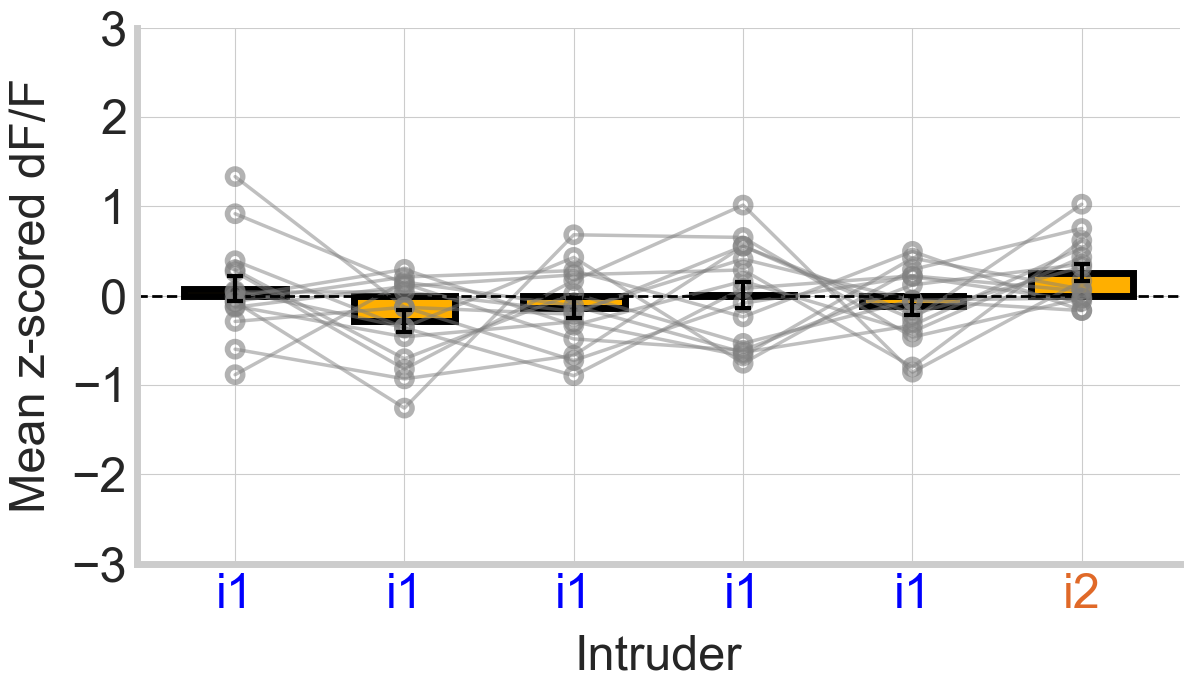


Paired t-test results:
  comparison  n  t_stat  p_value  cohen_d
s1-1 vs s1-2 15  1.9879   0.0667   0.5133
s1-1 vs s1-3 15  1.0319   0.3196   0.2664
s1-1 vs s1-4 15  0.2944   0.7727   0.0760
s1-1 vs s1-5 15  1.2532   0.2306   0.3236
s1-1 vs s2-1 15 -0.9190   0.3737  -0.2373
s1-2 vs s1-3 15 -0.7661   0.4564  -0.1978
s1-2 vs s1-4 15 -1.3157   0.2094  -0.3397
s1-2 vs s1-5 15 -1.1791   0.2580  -0.3045
s1-2 vs s2-1 15 -3.5072   0.0035  -0.9056
s1-3 vs s1-4 15 -0.8356   0.4174  -0.2157
s1-3 vs s1-5 15 -0.1543   0.8796  -0.0398
s1-3 vs s2-1 15 -2.5932   0.0213  -0.6696
s1-4 vs s1-5 15  0.5305   0.6041   0.1370
s1-4 vs s2-1 15 -1.4025   0.1825  -0.3621
s1-5 vs s2-1 15 -2.2769   0.0390  -0.5879


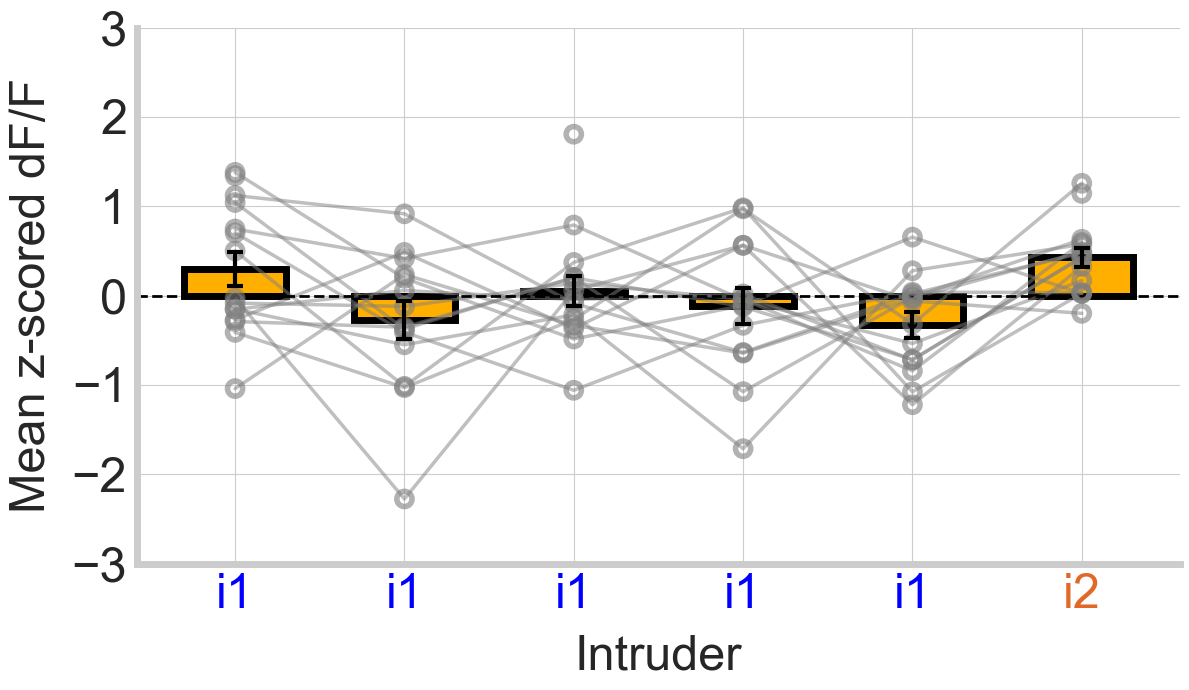


Paired t-test results:
  comparison  n  t_stat  p_value  cohen_d
s1-1 vs s1-2 14  1.9543   0.0725   0.5223
s1-1 vs s1-3 15  1.1952   0.2519   0.3086
s1-1 vs s1-4 14  1.1385   0.2754   0.3043
s1-1 vs s1-5 14  2.7596   0.0162   0.7375
s1-1 vs s2-1 15 -0.6023   0.5566  -0.1555
s1-2 vs s1-3 14 -0.7825   0.4480  -0.2091
s1-2 vs s1-4 14 -0.4614   0.6521  -0.1233
s1-2 vs s1-5 14  0.2793   0.7844   0.0747
s1-2 vs s2-1 14 -2.5571   0.0239  -0.6834
s1-3 vs s1-4 14  0.1728   0.8655   0.0462
s1-3 vs s1-5 14  1.0568   0.3098   0.2824
s1-3 vs s2-1 15 -2.4728   0.0268  -0.6385
s1-4 vs s1-5 14  0.6770   0.5103   0.1809
s1-4 vs s2-1 14 -2.1007   0.0557  -0.5614
s1-5 vs s2-1 14 -3.9184   0.0018  -1.0472


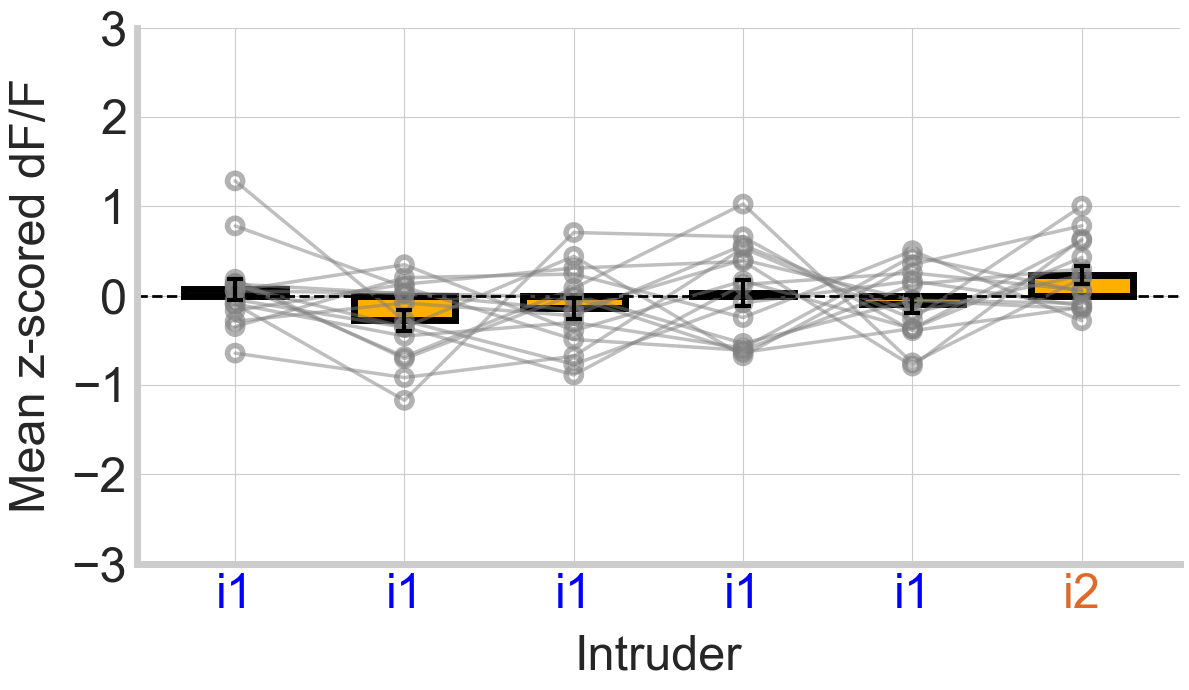


Paired t-test results:
  comparison  n  t_stat  p_value  cohen_d
s1-1 vs s1-2 15  2.3213   0.0359   0.5993
s1-1 vs s1-3 15  1.0929   0.2929   0.2822
s1-1 vs s1-4 15  0.1833   0.8572   0.0473
s1-1 vs s1-5 15  1.1394   0.2737   0.2942
s1-1 vs s2-1 15 -0.9178   0.3742  -0.2370
s1-2 vs s1-3 15 -0.7692   0.4545  -0.1986
s1-2 vs s1-4 15 -1.4895   0.1585  -0.3846
s1-2 vs s1-5 15 -1.2770   0.2224  -0.3297
s1-2 vs s2-1 15 -3.4289   0.0041  -0.8853
s1-3 vs s1-4 15 -0.9624   0.3522  -0.2485
s1-3 vs s1-5 15 -0.2791   0.7842  -0.0721
s1-3 vs s2-1 15 -2.3842   0.0318  -0.6156
s1-4 vs s1-5 15  0.5550   0.5876   0.1433
s1-4 vs s2-1 15 -1.1451   0.2714  -0.2957
s1-5 vs s2-1 15 -1.9626   0.0699  -0.5067


,BrainRegion,Window,WindowLabel,comparison,n,t_stat,p_value,cohen_d,p_adj,reject,significance
0,NAc,full_bout,Full Bout Mean,s1-1 vs s1-2,10,5.994002,0.000204,1.895470,0.002856,True,sig
1,NAc,full_bout,Full Bout Mean,s1-1 vs s1-3,10,4.939083,0.000803,1.561875,0.010442,True,sig
2,NAc,full_bout,Full Bout Mean,s1-1 vs s1-4,10,4.201452,0.002302,1.328616,0.026600,True,sig
3,NAc,full_bout,Full Bout Mean,s1-1 vs s1-5,10,4.204334,0.002292,1.329527,0.026600,True,sig
4,NAc,full_bout,Full Bout Mean,s1-1 vs s2-1,10,-0.258515,0.801824,-0.081750,1.000000,False,ns
5,NAc,full_bout,Full Bout Mean,s1-2 vs s1-3,10,-4.226923,0.002217,-1.336671,0.026600,True,sig
6,NAc,full_bout,Full Bout Mean,s1-2 vs s1-4,10,-0.762023,0.465546,-0.240973,1.000000,False,ns
7,NAc,full_bout,Full Bout Mean,s1-2 vs s1-5,10,-2.070351,0.068325,-0.654702,0.409951,False,ns
8,NAc,full_bout,Full Bout Mean,s1-2 vs s2-1,10,-6.108857,0.000177,-1.931790,0.002660,True,sig
9,NAc,full_bout,Full Bout Mean,s1-3 vs s1-4,10,1.421599,0.188856,0.449549,0.944278,False,ns


In [6]:
plot_results = {}
paired_stats_frames = []

for region_name in SELECTED_REGIONS:
    region_dir = OUTPUT_DIR / region_name
    region_dir.mkdir(parents=True, exist_ok=True)
    region_df = metadata_df[metadata_df['BrainRegion'] == region_name].copy()
    region_df = region_df[region_df['Bout'].astype(str).isin(BOUT_ORDER)].copy()
    region_df['Bout'] = pd.Categorical(region_df['Bout'].astype(str), categories=BOUT_ORDER, ordered=True)

    for window_name in WINDOW_ORDER:
        save_base = region_dir / f'{region_name}_{window_name}_{SIGNAL_NAME}'
        plot_df = region_df[region_df['Behavior'] == window_name].copy()
        plot_df = plot_df[plot_df['Bout'].astype(str).isin(BOUT_ORDER)].copy()
        plot_df['Bout'] = pd.Categorical(plot_df['Bout'].astype(str), categories=BOUT_ORDER, ordered=True)
        pivot_df, stats_df = plot_behavior_across_bouts_no_identities(
            metadata_df=plot_df,
            y_col=SIGNAL_COLUMN,
            behavior=window_name,
            title='',
            xlabel='Intruder',
            ylabel='Mean z-scored dF/F',
            custom_xtick_labels=CUSTOM_XTICK_LABELS,
            custom_xtick_colors=CUSTOM_XTICK_COLORS,
            ylim=REGION_CONFIGS[region_name]['ylim'],
            bar_color=REGION_CONFIGS[region_name]['color'],
            yticks_increment=YTICKS_INCREMENT,
            figsize=(12, 7),
            pad_inches=0.1,
            save=True,
            save_name=str(save_base) + '.png',
            save_stats=str(save_base) + '_paired_ttests.csv',
        )

        stats_df = stats_df.copy()
        stats_df.insert(0, 'BrainRegion', region_name)
        stats_df.insert(1, 'Window', window_name)
        stats_df.insert(2, 'WindowLabel', WINDOW_LABELS[window_name])
        stats_df = holm_correct_stats(stats_df)
        stats_df.to_csv(str(save_base) + '_paired_ttests_holm.csv', index=False)

        plot_results[(region_name, window_name)] = {
            'pivot_df': pivot_df,
            'stats_df': stats_df,
        }
        paired_stats_frames.append(stats_df)

all_plot_stats_df = pd.concat(paired_stats_frames, ignore_index=True)
all_plot_stats_df.to_csv(OUTPUT_DIR / f'{SIGNAL_NAME}_paired_ttests_all_plots.csv', index=False)
all_plot_stats_df.head(18)

In [7]:
within_bout_window_stats = pd.concat(
    [run_within_bout_window_stats(metadata_df, region_name) for region_name in SELECTED_REGIONS],
    ignore_index=True,
)
within_bout_window_stats.to_csv(OUTPUT_DIR / f'{SIGNAL_NAME}_within_bout_window_paired_ttests.csv', index=False)
within_bout_window_stats

,BrainRegion,Bout,comparison,n,t_stat,p_value,cohen_d,p_adj,reject,significance
0,NAc,s1-1,full_bout vs investigation,10,-5.838591,0.000247,-1.846325,0.000495,True,sig
1,NAc,s1-1,full_bout vs non_investigation,10,5.524581,0.000368,1.747026,0.000495,True,sig
2,NAc,s1-1,investigation vs non_investigation,10,6.754725,0.000083,2.136032,0.000250,True,sig
3,NAc,s1-2,full_bout vs investigation,10,-1.286463,0.230387,-0.406815,0.691160,False,ns
4,NAc,s1-2,full_bout vs non_investigation,10,0.555689,0.591967,0.175724,0.691160,False,ns
5,NAc,s1-2,investigation vs non_investigation,10,1.238534,0.246848,0.391659,0.691160,False,ns
6,NAc,s1-3,full_bout vs investigation,10,-0.105889,0.917993,-0.033485,1.000000,False,ns
7,NAc,s1-3,full_bout vs non_investigation,10,1.015549,0.336366,0.321145,1.000000,False,ns
8,NAc,s1-3,investigation vs non_investigation,10,0.135362,0.895305,0.042805,1.000000,False,ns
9,NAc,s1-4,full_bout vs investigation,9,-1.044448,0.326808,-0.348149,0.619460,False,ns


In [8]:
summary_df = (
    metadata_df.groupby(['BrainRegion', 'Behavior', 'Bout'], observed=True)[SIGNAL_COLUMN]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
summary_df['sem'] = summary_df['std'] / np.sqrt(summary_df['count'].clip(lower=1))
summary_df.to_csv(OUTPUT_DIR / f'{SIGNAL_NAME}_summary_by_region_window_bout.csv', index=False)
summary_df

,BrainRegion,Behavior,Bout,mean,std,count,sem
0,NAc,full_bout,s1-1,0.334518,0.241274,10,0.076298
1,NAc,full_bout,s1-2,-0.257289,0.186294,10,0.058911
2,NAc,full_bout,s1-3,-0.035990,0.102909,10,0.032543
3,NAc,full_bout,s1-4,-0.174636,0.236778,10,0.074876
4,NAc,full_bout,s1-5,-0.098755,0.269610,10,0.085258
5,NAc,full_bout,s2-1,0.370800,0.286383,10,0.090562
6,NAc,investigation,s1-1,1.290270,0.545412,10,0.172474
7,NAc,investigation,s1-2,-0.144802,0.375039,10,0.118598
8,NAc,investigation,s1-3,-0.021665,0.442532,10,0.139941
9,NAc,investigation,s1-4,-0.002929,0.373386,9,0.124462


## Output Notes

- `metadata_df` contains one row per subject, bout, region, and window.
- Each region/window plot is saved under `Hab_Dishab/mpfc_bout_mean_da_outputs/<region>/`.
- For each plot, raw paired t-tests and Holm-corrected paired t-tests are both saved.
- `within_bout_window_stats` compares `full_bout`, `investigation`, and `non_investigation` within each bout across subjects.